In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
student_vle = pd.read_csv("studentVle.csv", engine="python", on_bad_lines="skip")
vle = pd.read_csv("vle.csv", engine="python", on_bad_lines="skip")
assessments = pd.read_csv("assessments.csv", engine="python", on_bad_lines="skip")
student_assess = pd.read_csv("studentAssessment.csv", engine="python", on_bad_lines="skip")
student_reg = pd.read_csv("studentRegistration.csv", engine="python", on_bad_lines="skip")
student_info = pd.read_csv("studentInfo.csv", engine="python", on_bad_lines="skip")
courses = pd.read_csv("courses.csv", engine="python", on_bad_lines="skip")

# 2. Config
keys = ['id_student', 'code_module', 'code_presentation']
student_vle.drop_duplicates(inplace=True)
student_assess.drop_duplicates(inplace=True)

# 3. Fix date conversions
student_vle['date'] = pd.to_numeric(student_vle['date'], errors='coerce')
student_vle['sum_click'] = pd.to_numeric(student_vle['sum_click'], errors='coerce').fillna(0)

# 4. VLE Features with proper early/late split
vle_agg = student_vle.groupby(keys).agg(
    total_clicks=('sum_click', 'sum'),
    avg_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique'),
    max_date=('date', 'max')  # Get max date for splitting
).reset_index()

# Use 30% of course as "early" period (common in literature)
vle_agg['early_threshold'] = vle_agg['max_date'] * 0.3

# Merge back to get threshold for each student-course
student_vle = student_vle.merge(vle_agg[keys + ['early_threshold']], on=keys, how='left')

early_clicks = student_vle[student_vle['date'] <= student_vle['early_threshold']].groupby(keys)['sum_click'].sum().reset_index(name='early_clicks')
late_clicks = student_vle[student_vle['date'] > student_vle['early_threshold']].groupby(keys)['sum_click'].sum().reset_index(name='late_clicks')

vle_features = vle_agg[keys + ['total_clicks', 'avg_clicks', 'active_days']].merge(early_clicks, on=keys, how='left') \
                      .merge(late_clicks, on=keys, how='left').fillna(0)

# 5. Activity Type Features
activity_features = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left') \
    .groupby(keys + ['activity_type'])['sum_click'].sum().unstack(fill_value=0).reset_index()

# 6. Assessment Features - Only use data available by certain point if needed
student_assess['score'] = pd.to_numeric(student_assess['score'], errors='coerce')
student_assess = student_assess.dropna(subset=['score'])

merged_assess = pd.merge(student_assess, assessments, on='id_assessment')
merged_assess['weight'] = pd.to_numeric(merged_assess['weight'], errors='coerce').fillna(0)
merged_assess['weighted_score'] = merged_assess['score'] * merged_assess['weight'] / 100

assessment_features = merged_assess.groupby(keys).agg(
    avg_score=('score', 'mean'),
    total_score=('score', 'sum'),
    weighted_score=('weighted_score', 'sum'),
    num_assessments=('id_assessment', 'count')
).reset_index()

# 7. Registration Features - Fixed dropout calculation
student_reg['date_registration'] = pd.to_numeric(student_reg['date_registration'], errors='coerce')
student_reg['date_unregistration'] = pd.to_numeric(student_reg['date_unregistration'], errors='coerce')

# Get course length
student_reg = student_reg.merge(courses[['code_module', 'code_presentation', 'module_presentation_length']],
                               on=['code_module', 'code_presentation'], how='left')

# Calculate days active properly
student_reg['has_withdrawn'] = (student_reg['date_unregistration'] > 0).astype(int)
student_reg['days_active'] = student_reg['date_unregistration'].fillna(student_reg['module_presentation_length']) - student_reg['date_registration']
student_reg['days_registered'] = student_reg['module_presentation_length'] - student_reg['date_registration']

reg_features = student_reg[keys + ['days_active', 'has_withdrawn', 'date_registration', 'days_registered']]

# 8. Merge All - Keep keys for reference
data = student_info.merge(vle_features, on=keys, how='left') \
                   .merge(activity_features, on=keys, how='left') \
                   .merge(assessment_features, on=keys, how='left') \
                   .merge(reg_features, on=keys, how='left')

# 9. Create target (1 = at-risk: Fail or Withdrawn)
data['target'] = data['final_result'].apply(lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0)

# 10. Remove sensitive/leaky columns before prediction
drop_cols = ['id_student', 'final_result']  # Keep code_module/presentation for grouping if needed
data = data.drop(columns=[col for col in drop_cols if col in data.columns])

# 11. Fill NaNs
num_cols = data.select_dtypes(include=[np.number]).columns
data[num_cols] = data[num_cols].fillna(0)

# 12. Encode categoricals (but keep code_module/presentation for now)
cat_cols = data.select_dtypes(include=['object']).columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    le_dict[col] = le  # Store for potential inverse transform later

print(f"Final Shape: {data.shape}")
print(f"Target distribution:\n{data['target'].value_counts(normalize=True)}")
print(data.head())

# Save
data.to_csv("ml_training.csv", index=False)

Final Shape: (32593, 33)
Target distribution:
target
1    0.527966
0    0.472034
Name: proportion, dtype: float64
   code_module  code_presentation  gender  region  highest_education  \
0            0                  1       1       0                  1   
1            0                  1       0       6                  1   
2            0                  1       0       5                  0   
3            0                  1       0       7                  0   
4            0                  1       0      11                  2   

   imd_band  age_band  num_of_prev_attempts  studied_credits  disability  ...  \
0         9         2                     0              240           0  ...   
1         2         1                     0               60           0  ...   
2         3         1                     0               60           1  ...   
3         5         1                     0               60           0  ...   
4         5         0                     0     

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, StackingClassifier)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ==================== 1. LOAD AND PREPARE DATA ====================
print("="*60)
print("LOADING AND PREPARING DATA")
print("="*60)

# Load your preprocessed data
data = pd.read_csv("ml_training.csv")
print(f"Dataset shape: {data.shape}")
print(f"\nTarget distribution:")
print(data['target'].value_counts())
print(f"\nTarget distribution (%):")
print(data['target'].value_counts(normalize=True) * 100)

# Separate features and target
X = data.drop('target', axis=1)
y = data['target']

# Get feature names
feature_names = X.columns.tolist()
print(f"\nNumber of features: {len(feature_names)}")



LOADING AND PREPARING DATA
Dataset shape: (32593, 33)

Target distribution:
target
1    17208
0    15385
Name: count, dtype: int64

Target distribution (%):
target
1    52.796613
0    47.203387
Name: proportion, dtype: float64

Number of features: 32


In [3]:
# ==================== 2. TRAIN-TEST SPLIT ====================
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set target distribution:")
print(y_test.value_counts(normalize=True))


TRAIN-TEST SPLIT
Training set size: (26074, 32)
Test set size: (6519, 32)

Training set target distribution:
target
1    0.527959
0    0.472041
Name: proportion, dtype: float64

Test set target distribution:
target
1    0.527995
0    0.472005
Name: proportion, dtype: float64


In [4]:
# ==================== 3. FEATURE SCALING ====================
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

print("Features standardized (mean=0, std=1)")


FEATURE SCALING
Features standardized (mean=0, std=1)


In [5]:
# ==================== 4. INDIVIDUAL MODEL EVALUATION ====================
print("\n" + "="*60)
print("INDIVIDUAL MODEL EVALUATION")
print("="*60)

# Define models with default parameters
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE)
}

# Perform cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, model in models.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

    # Train on full training set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    results.append({
        'Model': name,
        'CV Mean Acc': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': auc
    })

    print(f"\n{name}:")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  F1 Score: {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("INDIVIDUAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(results_df.to_string(index=False))


INDIVIDUAL MODEL EVALUATION

Logistic Regression:
  CV Accuracy: 0.9243 (+/- 0.0051)
  Test Accuracy: 0.9244
  F1 Score: 0.9266

K-Nearest Neighbors:
  CV Accuracy: 0.9190 (+/- 0.0043)
  Test Accuracy: 0.9167
  F1 Score: 0.9170

Decision Tree:
  CV Accuracy: 0.9199 (+/- 0.0049)
  Test Accuracy: 0.9215
  F1 Score: 0.9261

Naive Bayes:
  CV Accuracy: 0.8497 (+/- 0.0128)
  Test Accuracy: 0.8543
  F1 Score: 0.8718

Random Forest:
  CV Accuracy: 0.9455 (+/- 0.0042)
  Test Accuracy: 0.9459
  F1 Score: 0.9474

AdaBoost:
  CV Accuracy: 0.9315 (+/- 0.0051)
  Test Accuracy: 0.9299
  F1 Score: 0.9311

INDIVIDUAL MODEL PERFORMANCE SUMMARY
              Model  CV Mean Acc   CV Std  Test Accuracy  Precision   Recall  F1 Score      AUC
Logistic Regression     0.924293 0.005126       0.924375   0.949680 0.904707  0.926648 0.975755
K-Nearest Neighbors     0.918962 0.004340       0.916705   0.967732 0.871296  0.916985 0.956879
      Decision Tree     0.919882 0.004886       0.921460   0.920494 0.931726

In [6]:
# ==================== 5. HYPERPARAMETER OPTIMIZATION ====================
print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION")
print("="*60)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define parameter grids for all models used in the paper
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11, 13],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.5, 1.0, 1.5],
        'algorithm': ['SAMME', 'SAMME.R']
    }
}

best_models = {}

# Loop over all models we want to optimize
for name, param_grid in param_grids.items():
    print(f"\nOptimizing {name}...")

    # Get base model
    if name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    elif name == 'K-Nearest Neighbors':
        base_model = KNeighborsClassifier()
    elif name == 'Decision Tree':
        base_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    elif name == 'Naive Bayes':
        base_model = GaussianNB()
    elif name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=RANDOM_STATE)
    elif name == 'AdaBoost':
        base_model = AdaBoostClassifier(random_state=RANDOM_STATE)

    # Use RandomizedSearchCV for heavier models, GridSearchCV for lighter ones
    if name in ['Random Forest', 'AdaBoost']:
        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grid,
            n_iter=15,
            cv=3,
            scoring='accuracy',
            n_jobs=2,
            verbose=2,
            random_state=RANDOM_STATE
        )
    else:
        search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=5,
            scoring='accuracy',
            n_jobs=2,
            verbose=2
        )

    search.fit(X_train_scaled, y_train)

    best_models[name] = search.best_estimator_
    print(f"  Best parameters: {search.best_params_}")
    print(f"  Best CV score: {search.best_score_:.4f}")

    # Evaluate on test set
    y_pred = search.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"  Test accuracy: {accuracy:.4f}")


HYPERPARAMETER OPTIMIZATION

Optimizing Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV score: 0.9242
  Test accuracy: 0.9244

Optimizing K-Nearest Neighbors...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best parameters: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
  Best CV score: 0.9240
  Test accuracy: 0.9231

Optimizing Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
  Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
  Best CV score: 0.9423
  Test accuracy: 0.9408

Optimizing Naive Bayes...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
  Best parameters: {'var_smoothing': 1e-09}
  Best CV score: 0.8499
  Test accuracy: 0.8543

Optimizing Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Best parameter

In [7]:
# ==================== 6. STACKING ENSEMBLE MODEL (as per paper) ====================
print("\n" + "="*60)
print("STACKING ENSEMBLE MODEL")
print("="*60)

# Base learners exactly as in the paper (LR, KNN, DT, NB, RF, AdaBoost)
# Use the optimized versions from best_models (if available) or fallback to defaults.
base_learners = [
    ('lr', best_models.get('Logistic Regression', LogisticRegression(random_state=RANDOM_STATE))),
    ('knn', best_models.get('K-Nearest Neighbors', KNeighborsClassifier())),
    ('dt', best_models.get('Decision Tree', DecisionTreeClassifier(random_state=RANDOM_STATE))),
    ('nb', best_models.get('Naive Bayes', GaussianNB())),
    ('rf', best_models.get('Random Forest', RandomForestClassifier(random_state=RANDOM_STATE))),
    ('ada', best_models.get('AdaBoost', AdaBoostClassifier(random_state=RANDOM_STATE)))
]

# Use SVM as meta-learner (paper's best). You can test other meta-learners if desired,
# but the final model will use SVM.
meta_learner = SVC(probability=True, random_state=RANDOM_STATE)

# Create stacking classifier with 10-fold CV as in the paper
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=10,
    stack_method='predict_proba'
)

# Train
stacking_clf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = stacking_clf.predict(X_test_scaled)
y_pred_proba = stacking_clf.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("STACKING MODEL PERFORMANCE (PAPER'S CONFIGURATION)")
print("="*60)
print(f"Base learners: LR, KNN, DT, NB, RF, AdaBoost")
print(f"Meta-learner: SVM")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")


final_stacking = stacking_clf


STACKING ENSEMBLE MODEL

STACKING MODEL PERFORMANCE (PAPER'S CONFIGURATION)
Base learners: LR, KNN, DT, NB, RF, AdaBoost
Meta-learner: SVM
Accuracy:  0.9435
Precision: 0.9788
Recall:    0.9128
F1 Score:  0.9447
AUC:       0.9640


In [8]:
# ==================== 7. COMPARATIVE ANALYSIS ====================
print("\n" + "="*60)
print("COMPARATIVE ANALYSIS")
print("="*60)
best_meta = 'SVM'
# Get best individual model
best_individual_idx = results_df['F1 Score'].idxmax()
best_individual_name = results_df.iloc[best_individual_idx]['Model']
best_individual_model = models[best_individual_name]

# If the best model was optimized, use optimized version
if best_individual_name in best_models:
    best_individual_model = best_models[best_individual_name]

# Retrain best individual model
best_individual_model.fit(X_train_scaled, y_train)
y_pred_individual = best_individual_model.predict(X_test_scaled)
y_pred_proba_individual = best_individual_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_individual_model, 'predict_proba') else None

# Get stacking predictions
y_pred_stacking = final_stacking.predict(X_test_scaled)
y_pred_proba_stacking = final_stacking.predict_proba(X_test_scaled)[:, 1]

# Compare metrics
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'],
    f'Best Individual ({best_individual_name})': [
        accuracy_score(y_test, y_pred_individual),
        precision_score(y_test, y_pred_individual),
        recall_score(y_test, y_pred_individual),
        f1_score(y_test, y_pred_individual),
        roc_auc_score(y_test, y_pred_proba_individual) if y_pred_proba_individual is not None else None
    ],
    f'Stacking Ensemble (Meta: {best_meta})': [
        accuracy_score(y_test, y_pred_stacking),
        precision_score(y_test, y_pred_stacking),
        recall_score(y_test, y_pred_stacking),
        f1_score(y_test, y_pred_stacking),
        roc_auc_score(y_test, y_pred_proba_stacking)
    ]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))


COMPARATIVE ANALYSIS

MODEL COMPARISON
   Metric  Best Individual (Random Forest)  Stacking Ensemble (Meta: SVM)
 Accuracy                         0.945851                       0.943550
Precision                         0.973047                       0.978816
   Recall                         0.923010                       0.912841
 F1 Score                         0.947368                       0.944678
      AUC                         0.984576                       0.963961


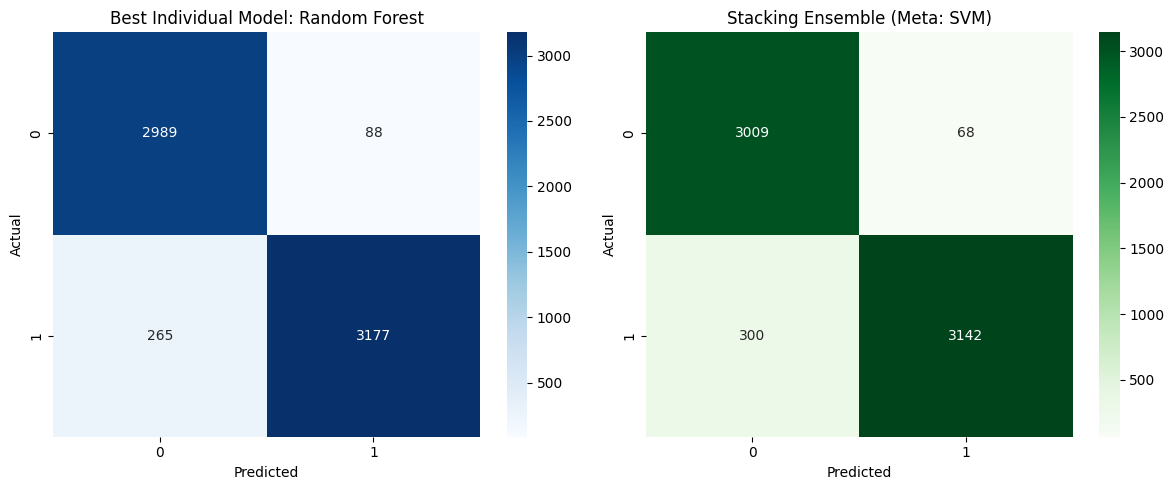

In [9]:
# ==================== 8. CONFUSION MATRICES ====================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
best_meta = 'SVM'
# Individual model confusion matrix
cm_individual = confusion_matrix(y_test, y_pred_individual)
sns.heatmap(cm_individual, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Best Individual Model: {best_individual_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Stacking model confusion matrix
cm_stacking = confusion_matrix(y_test, y_pred_stacking)
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Stacking Ensemble (Meta: {best_meta})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

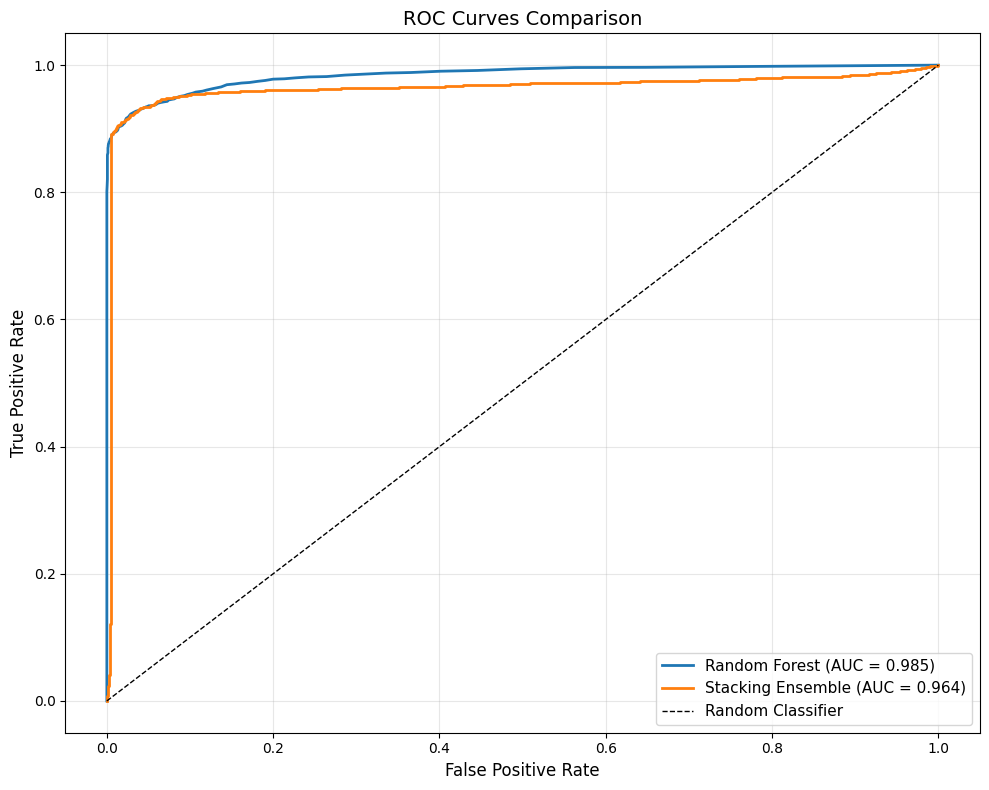

In [10]:
# ==================== 9. ROC CURVES ====================
plt.figure(figsize=(10, 8))

# Individual model ROC
if y_pred_proba_individual is not None:
    fpr_individual, tpr_individual, _ = roc_curve(y_test, y_pred_proba_individual)
    auc_individual = roc_auc_score(y_test, y_pred_proba_individual)
    plt.plot(fpr_individual, tpr_individual, label=f'{best_individual_name} (AUC = {auc_individual:.3f})', linewidth=2)

# Stacking model ROC
fpr_stacking, tpr_stacking, _ = roc_curve(y_test, y_pred_proba_stacking)
auc_stacking = roc_auc_score(y_test, y_pred_proba_stacking)
plt.plot(fpr_stacking, tpr_stacking, label=f'Stacking Ensemble (AUC = {auc_stacking:.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
          feature  importance
      total_score    0.249756
   weighted_score    0.248710
  num_assessments    0.125737
      days_active    0.105711
        avg_score    0.094502
    has_withdrawn    0.039011
      code_module    0.023807
date_registration    0.018174
  days_registered    0.017069
  studied_credits    0.014476


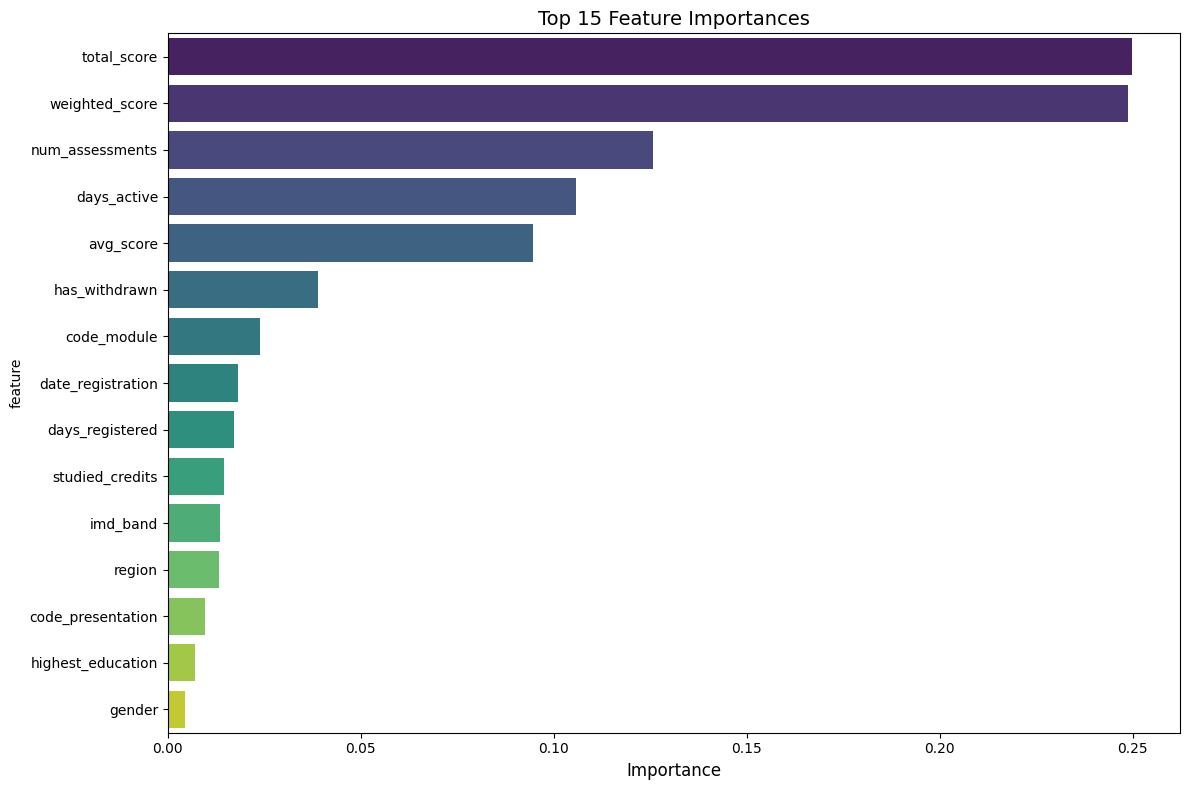

In [11]:
# ==================== 10. FEATURE IMPORTANCE ====================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Random Forest
if 'Random Forest' in best_models:
    rf_model = best_models['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
    plt.title('Top 15 Feature Importances', fontsize=14)
    plt.xlabel('Importance', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

In [12]:
# ==================== 11. CROSS-VALIDATION RESULTS ====================
print("\n" + "="*60)
print("CROSS-VALIDATION DETAILS")
print("="*60)

# Perform 10-fold CV on best models
cv_models = {
    'Best Individual': best_individual_model,
    'Stacking Ensemble': final_stacking
}

for name, model in cv_models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=10, scoring='f1')
    print(f"\n{name} 10-Fold CV F1 Scores:")
    print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Min: {cv_scores.min():.4f}, Max: {cv_scores.max():.4f}")


CROSS-VALIDATION DETAILS

Best Individual 10-Fold CV F1 Scores:
  Mean: 0.9473 (+/- 0.0052)
  Min: 0.9376, Max: 0.9585

Stacking Ensemble 10-Fold CV F1 Scores:
  Mean: 0.9469 (+/- 0.0051)
  Min: 0.9362, Max: 0.9570


In [13]:
# ==================== 12. SAVE BEST MODEL ====================
print("\n" + "="*60)
print("SAVING BEST MODEL")
print("="*60)

import joblib

# Save the best model (stacking ensemble)
model_filename = 'best_stacking_model.pkl'
scaler_filename = 'scaler.pkl'

joblib.dump(final_stacking, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"Best stacking model saved to: {model_filename}")
print(f"Scaler saved to: {scaler_filename}")

# Save model performance summary
performance_summary = {
    'best_individual': {
        'name': best_individual_name,
        'metrics': comparison.iloc[:, 1].to_dict()
    },
    'stacking_ensemble': {
        'meta_learner': best_meta,
        'metrics': comparison.iloc[:, 2].to_dict()
    }
}

import json
with open('model_performance.json', 'w') as f:
    json.dump(performance_summary, f, indent=4)

print("Performance summary saved to: model_performance.json")


SAVING BEST MODEL
Best stacking model saved to: best_stacking_model.pkl
Scaler saved to: scaler.pkl
Performance summary saved to: model_performance.json


In [14]:
# ==================== 13. FINAL SUMMARY ====================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"""
Dataset Size: {len(data)} students
Features Used: {len(feature_names)}

Best Individual Model: {best_individual_name}
  - Test Accuracy: {comparison.iloc[0, 1]:.4f}
  - F1 Score: {comparison.iloc[3, 1]:.4f}
  - AUC: {comparison.iloc[4, 1]:.4f}

Best Stacking Ensemble (Meta: {best_meta}):
  - Test Accuracy: {comparison.iloc[0, 2]:.4f}
  - F1 Score: {comparison.iloc[3, 2]:.4f}
  - AUC: {comparison.iloc[4, 2]:.4f}

Improvement:
  - Accuracy: +{((comparison.iloc[0, 2] - comparison.iloc[0, 1])/comparison.iloc[0, 1]*100):.2f}%
  - F1 Score: +{((comparison.iloc[3, 2] - comparison.iloc[3, 1])/comparison.iloc[3, 1]*100):.2f}%
""")


FINAL SUMMARY

Dataset Size: 32593 students
Features Used: 32

Best Individual Model: Random Forest
  - Test Accuracy: 0.9459
  - F1 Score: 0.9474
  - AUC: 0.9846

Best Stacking Ensemble (Meta: SVM):
  - Test Accuracy: 0.9435
  - F1 Score: 0.9447
  - AUC: 0.9640

Improvement:
  - Accuracy: +-0.24%
  - F1 Score: +-0.28%



In [15]:
# ==================== 14. QUICK PREDICTION FUNCTION ====================
def predict_student_risk(student_data, model=final_stacking, scaler=scaler, feature_names=feature_names):
    """
    Quick function to predict if a student is at-risk

    Parameters:
    student_data: dict or DataFrame with feature values
    model: trained model
    scaler: fitted scaler
    feature_names: list of feature names

    Returns:
    prediction and probability
    """
    if isinstance(student_data, dict):
        student_df = pd.DataFrame([student_data])
    else:
        student_df = student_data.copy()

    # Ensure all features are present
    for feat in feature_names:
        if feat not in student_df.columns:
            student_df[feat] = 0

    # Reorder columns to match training
    student_df = student_df[feature_names]

    # Scale
    student_scaled = scaler.transform(student_df)

    # Predict
    pred = model.predict(student_scaled)[0]
    proba = model.predict_proba(student_scaled)[0]

    result = {
        'prediction': 'At-Risk' if pred == 1 else 'Not At-Risk',
        'probability_at_risk': proba[1],
        'probability_safe': proba[0]
    }

    return result

print("\n" + "="*60)
print("PREDICTION FUNCTION READY")
print("="*60)
print("""
Usage:
    result = predict_student_risk(student_data)
    print(result['prediction'])
    print(f"Risk probability: {result['probability_at_risk']:.2%}")
""")

# Example usage with first test student
example_student = X_test.iloc[0].to_dict()
example_result = predict_student_risk(example_student)
print("\nExample Prediction:")
print(f"Actual: {'At-Risk' if y_test.iloc[0] == 1 else 'Not At-Risk'}")
print(f"Predicted: {example_result['prediction']}")
print(f"Risk Probability: {example_result['probability_at_risk']:.2%}")


PREDICTION FUNCTION READY

Usage:
    result = predict_student_risk(student_data)
    print(result['prediction'])
    print(f"Risk probability: {result['probability_at_risk']:.2%}")


Example Prediction:
Actual: Not At-Risk
Predicted: Not At-Risk
Risk Probability: 6.95%
